# Test 1: can the encoder read X off the pixels at all?

This notebook trains the **same encoder the Residual SCBM uses**, on the **same input**,
under the **same optimisation**, with one linear logit on top of the shared feature
vector — supervised directly on X. The only thing that differs from the real run is the
loss.

```
concepts (supervised)   A  = 1[d1 >= 5]      parent of X
                        B  = 1[d2 >= 5]      parent of X
                        D1 = 1[d3 >= 5]      distractor
                        D2 = 1[d4 >= 5]      distractor

hidden (oracle only)    X  = 1[d1 + d2 >= 10]        the addition carry
```

**Why this matters.** If the residual channel turns out not to carry X, that means one
thing when the encoder *could* have read X from these pixels and something entirely
different when it could not. This measures the ceiling, so the residual result has
something to be compared against.

**What it does not tell you.** A supervised read-out trained on X says what is
*recoverable* from the image — not what an unsupervised residual channel would
spontaneously organise itself around. The real residual result can only be worse.

The batch equivalent is `encoder_capacity_check.py`; this notebook imports its config,
ceiling and evaluation helpers so those cannot drift, and keeps the training loop inline
where you can watch and edit it.

## 1. Setup

In [3]:
import os
import sys
from pathlib import Path

REPO_DEFAULT = Path(
    "/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation"
)


def find_repo_root(start=None):
    """First ancestor holding the repo's configs/ and models/, else REPO_DEFAULT."""
    marker = Path("models") / "models.py"
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / marker).exists() and (candidate / "configs" / "config.yaml").exists():
            return candidate
    if (REPO_DEFAULT / marker).exists():
        return REPO_DEFAULT
    raise FileNotFoundError(f"SCBM checkout not found from {Path.cwd()}; set REPO_DEFAULT.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
print(f"repo root: {REPO_ROOT}")

repo root: /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation


In [4]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from datasets.MNIST_add_cov_dataset import get_MNIST_add_cov_datasets
from models.models import IntCEMMNISTEncoder
from utils.utils import reset_random_seeds

# Imported rather than restated, so the notebook and the script cannot disagree
# about what "matched" means.
from encoder_capacity_check import (
    build_config,
    concept_only_ceiling,
    evaluate,
    pick_device,
    target_extractor,
)

%matplotlib inline

/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Plot style

Two series at most per chart, from the reference categorical palette (slots 1 and 2).
Reference lines and all text stay in ink colours — a coloured mark beside a label carries
identity, the text never does. No dual axes anywhere: train loss and the validation
metrics live in separate panels because they are on different scales.

In [5]:
SERIES_1 = "#2a78d6"   # blue    - accuracy
SERIES_2 = "#eb6834"   # orange   - AUROC
INK      = "#0b0b0b"
INK_2    = "#52514e"
INK_MUTE = "#8a8a86"
GRID     = "#e4e4e1"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "medium",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "lines.linewidth": 2.0,
    "lines.markersize": 8,
    "text.color": INK,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "font.size": 10,
    "legend.frameon": False,
})

## 2. Configuration

`--run` in the script becomes `RUN` here: it reads that run's `log.txt` and overlays the
**entire** recorded `data` and `model` dict, so nothing silently falls back to a config
default that has been edited since. `CORRUPTION` is applied *after* that overlay, which
makes it a single clean axis against a fully pinned baseline.

Set `RUN = None` to compose from `configs/` instead.

In [6]:
RUN = ("planted_xor_MNIST_ADD_carry_corr_strength_02_global_no_prec_emp_perc_"
       "residuals_1_L_int_extension_loss_weight_1_2026-09-07_16-41-10_ec22a")
TARGET = "X"           # or a supervised concept: A, B, D1, D2
CORRUPTION = None      # None -> whatever RUN used; a float overrides it
NUM_COVARIATES = None  # None -> 4 (matched); 2 drops the distractor channels
EPOCHS = None          # None -> the run's j_epochs
SEED = None            # None -> the run's seed

args = SimpleNamespace(
    run=RUN,
    target=TARGET,
    corruption_strength=CORRUPTION,
    num_covariates=NUM_COVARIATES,
    epochs=EPOCHS,
    seed=SEED,
)
config = build_config(args)
m = config.model

print(f"experiment      : {config.data.experiment}")
print(f"corruption      : {config.data.corruption} @ {config.data.corruption_strength}, "
      f"p={config.data.corruption_probability}")
print(f"optimiser       : {m.optimizer} lr={m.learning_rate} wd={m.weight_decay}, "
      f"StepLR(every {m.decrease_every}, /{m.lr_divisor})")
print(f"batch size      : train {m.train_batch_size} (drop_last), val/test {m.val_batch_size}")
print(f"epochs          : {m.j_epochs}, early stop patience {m.early_stopping_patience}")

hyperparameters from: planted_xor_MNIST_ADD_carry_corr_strength_02_global_no_prec_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-07_16-41-10_ec22a
experiment      : hidden_carry
corruption      : gaussian @ 0.2, p=1.0
optimiser       : adam lr=0.0001 wd=0, StepLR(every 150, /2)
batch size      : train 64 (drop_last), val/test 64
epochs          : 200, early stop patience 30


## 3. Data

Same generator seeding and the same `get_MNIST_add_cov_datasets` call `train.py` makes,
so the split fingerprints below should match the real run's. Corruption noise is drawn
deterministically per `(sample, channel)` from the seed, so it is **fixed across epochs** —
inherited for free by using the same dataset class.

In [7]:
gen = reset_random_seeds(config.seed)
# The conv backward pass has no deterministic CUDA kernel; reset_random_seeds turns on
# strict determinism, so relax that one bit. All the seeding itself is preserved.
torch.use_deterministic_algorithms(False)
device = pick_device()

trainset, valset, testset = get_MNIST_add_cov_datasets(
    config.data, config.incomplete, seed=config.seed
)
extract, target_label = target_extractor(trainset, TARGET)

train_loader = DataLoader(
    trainset, batch_size=m.train_batch_size, shuffle=True,
    num_workers=config.workers, pin_memory=True, generator=gen,
    drop_last=True, persistent_workers=True,
)
val_loader = DataLoader(
    valset, batch_size=m.val_batch_size, shuffle=True,
    num_workers=config.workers, pin_memory=True, generator=gen,
    persistent_workers=True,
)
test_loader = DataLoader(
    testset, batch_size=m.val_batch_size, num_workers=config.workers, generator=gen,
)

print(f"\ntarget          : {target_label}")
print(f"input           : {tuple(trainset[0]['features'].shape)}")
print(f"corrupted chans : {list(trainset.corruption_channels)}")
print(f"device          : {device}")

MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=07d39532c610848c
  val   n=2400   sha256[:16]=4f810f3a2dc12679
  test  n=10000  sha256[:16]=0bc1b3b34e2bfd54
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).

target          : X (the carry, oracle-only)
input           : (4, 28, 28)
corrupted chans : [0, 1, 2, 3]
device          : mps


### What the encoder is being asked to read

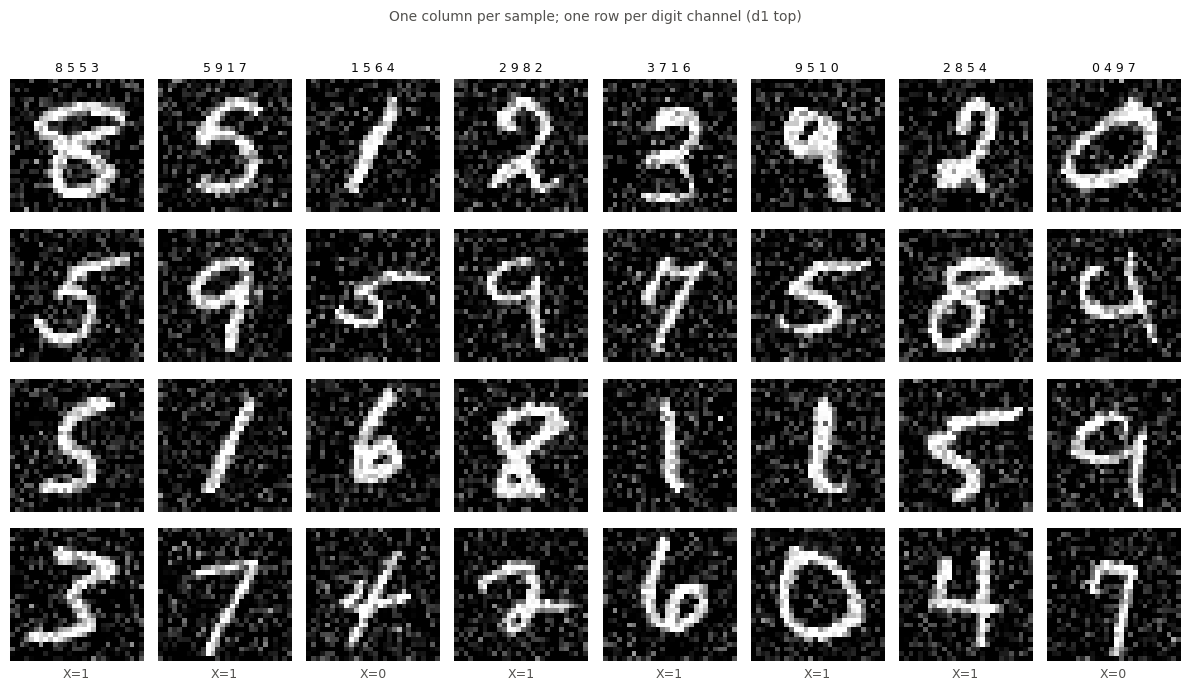

In [8]:
def show_samples(dataset, indices):
    indices = list(indices)
    n_ch = dataset[indices[0]]["features"].shape[0]
    fig, axes = plt.subplots(n_ch, len(indices), figsize=(1.5 * len(indices), 1.7 * n_ch))
    for col, index in enumerate(indices):
        item = dataset[index]
        digits = item["digit_labels"].tolist()
        for ch in range(n_ch):
            ax = axes[ch, col]
            ax.imshow(item["features"][ch], cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for s in ax.spines.values():
                s.set_visible(False)
        axes[0, col].set_title(" ".join(str(d) for d in digits), fontsize=9, loc="center")
        axes[-1, col].set_xlabel(f"X={int(item['X'])}", fontsize=9, color=INK_2)
    fig.suptitle("One column per sample; one row per digit channel (d1 top)",
                 fontsize=10, color=INK_2, y=1.01)
    plt.tight_layout()
    plt.show()


show_samples(trainset, range(8))

## 4. The two ceilings

The bar is not 0.5. X is a deterministic function of d1 and d2, and A, B are *also*
functions of d1, d2 — so a predictor with no access to the image at all still does well
just by knowing (A, B):

| (A, B) | P(X = 1) | |
|---|---|---|
| (0, 0) | 0.0 | X pinned |
| (0, 1) | 0.4 | ambiguous |
| (1, 0) | 0.4 | ambiguous |
| (1, 1) | 1.0 | X pinned |

**Accuracy ceiling = 0.80.** Predict the cell majority: correct on the 50% where A == B,
60% correct on the rest.

**AUROC ceiling ≈ 0.8788.** Score each sample by its cell's P(X=1). The two ambiguous
cells tie with each other, contributing half credit.

Both are reported because accuracy alone is too coarse here: the entire span between
"knows nothing" and "reads X perfectly" is only 0.20 wide, and thresholding at 0.5 throws
away everything the model knows about the ambiguous cells. **AUROC is the sensitive
test**; accuracy corroborates.

In [9]:
ceiling_acc, ceiling_auroc = concept_only_ceiling(trainset, extract, config.workers)
print(f"concept-only ceiling   accuracy {ceiling_acc:.4f}   AUROC {ceiling_auroc:.4f}")

# Cross-check the AUROC bar analytically against the generator's own probabilities,
# rather than trusting the empirical estimate alone.
pos = {0.0: 0.0, 0.4: 0.25 * 0.4 * 2, 1.0: 0.25}
neg = {0.0: 0.25, 0.4: 0.25 * 0.6 * 2, 1.0: 0.0}
P, N = sum(pos.values()), sum(neg.values())
analytic = sum(
    p / P * n / N * (1.0 if sp > sn else 0.5 if sp == sn else 0.0)
    for sp, p in pos.items() for sn, n in neg.items() if p and n
)
print(f"analytic AUROC ceiling {analytic:.4f}   (agrees: {abs(analytic - ceiling_auroc) < 1e-3})")

concept-only ceiling   accuracy 0.8000   AUROC 0.8788
analytic AUROC ceiling 0.8788   (agrees: True)


## 5. The model

The encoder up to the **shared feature vector** — the same 128-d output that feeds both
the concept heads and the residual head in the real model — plus one linear logit. Not the
concept-head parameterisation, not the residual-head one, no extra hidden layer. That is
what keeps "encoder capacity" meaning the same thing in both models.

In [10]:
def build_model(config, device):
    in_channels = int(config.data.num_covariates)
    encoder = IntCEMMNISTEncoder(in_channels=in_channels, output_dim=128)
    return nn.Sequential(encoder, nn.Linear(128, 1)).to(device)


model = build_model(config, device)
print(model)
print(f"\n{sum(p.numel() for p in model.parameters()):,} parameters")


Sequential(
  (0): IntCEMMNISTEncoder(
    (encoder): Sequential(
      (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): LeakyReLU(negative_slope=0.01)
      (8): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): LeakyReLU(negative_slope=0.01)
      (11): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (12): Conv2d(32

## 6. Training

`train.py`'s loop ordering, including its **validate-before-train** quirk: the validation
at epoch 0 scores the untrained model, and the checkpoint kept is always the state at the
end of the previous epoch. Keeping that identical means epoch numbers mean the same thing
in both.

The one deliberate deviation: early stopping tracks val accuracy on **X**, since X is the
only target here. `train.py` tracks `y_accuracy` on the task label.

In [11]:
def train_encoder(config, model, loaders, extract, device, verbose=True):
    """train.py's joint loop, with X as the target and the early-stopping metric."""
    m = config.model
    train_loader, val_loader = loaders["train"], loaders["val"]

    optimizer = optim.Adam([{
        "params": filter(lambda p: p.requires_grad, model.parameters()),
        "lr": m.learning_rate,
        "weight_decay": m.weight_decay,
    }])
    lr_scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=m.decrease_every, gamma=1 / m.lr_divisor,
    )
    criterion = nn.BCEWithLogitsLoss()

    history = {"epoch": [], "train_loss": [], "val_acc": [], "val_auroc": []}
    best = {"val_acc": float("-inf"), "epoch": -1, "state": None}
    epochs_without_improvement = 0

    if verbose:
        print(f"{'epoch':>6}  {'train_loss':>10}  {'val_acc':>8}  {'val_auroc':>9}")

    for epoch in range(0, m.j_epochs):
        # Validate first, exactly as train.py does.
        val_acc, val_auroc = evaluate(model, val_loader, extract, device)

        if val_acc > best["val_acc"]:
            best = {
                "val_acc": val_acc,
                "epoch": epoch,
                "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= m.early_stopping_patience:
            if verbose:
                print(f"Early stopping: no improvement for {m.early_stopping_patience} "
                      f"epochs. Best val accuracy {best['val_acc']:.4f}")
            break

        model.train()
        running, seen = 0.0, 0
        for batch in train_loader:
            x = batch["features"].to(device)
            t = extract(batch).float().to(device)

            optimizer.zero_grad()
            loss = criterion(model(x).squeeze(1), t)
            loss.backward()
            optimizer.step()

            running += loss.item() * x.size(0)
            seen += x.size(0)

        lr_scheduler.step()
        train_loss = running / seen

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_auroc"].append(val_auroc)

        if verbose:
            print(f"{epoch:>6}  {train_loss:>10.4f}  {val_acc:>8.4f}  {val_auroc:>9.4f}")

    model.load_state_dict(best["state"])
    return history, best

In [12]:
loaders = {"train": train_loader, "val": val_loader, "test": test_loader}
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# history, best = train_encoder(config, model, loaders, extract, device)


### Training curves

Two panels, not one with two y-axes: loss and the [0, 1] metrics are on different scales,
and a dual-axis chart lets the reader infer a crossing point that does not exist.

In [13]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# fig, (ax_loss, ax_val) = plt.subplots(1, 2, figsize=(11, 3.8))
#
# ax_loss.plot(history["epoch"], history["train_loss"], color=SERIES_1)
# ax_loss.set_title("Train loss")
# ax_loss.set_xlabel("epoch")
# ax_loss.set_ylabel("BCE")
#
# ax_val.plot(history["epoch"], history["val_acc"], color=SERIES_1, label="accuracy")
# ax_val.plot(history["epoch"], history["val_auroc"], color=SERIES_2, label="AUROC")
# ax_val.axhline(ceiling_acc, color=INK_MUTE, linestyle="--", linewidth=1.2)
# ax_val.axhline(ceiling_auroc, color=INK_MUTE, linestyle=":", linewidth=1.2)
# ax_val.annotate(f"accuracy ceiling {ceiling_acc:.3f}", xy=(0.02, ceiling_acc),
#                 xycoords=("axes fraction", "data"), va="bottom", fontsize=8, color=INK_2)
# ax_val.annotate(f"AUROC ceiling {ceiling_auroc:.3f}", xy=(0.02, ceiling_auroc),
#                 xycoords=("axes fraction", "data"), va="bottom", fontsize=8, color=INK_2)
# ax_val.axvline(best["epoch"], color=INK_MUTE, linewidth=1.0, alpha=0.6)
# ax_val.set_title("Validation — dashed lines are what (A, B) alone achieves")
# ax_val.set_xlabel("epoch")
# ax_val.legend(loc="lower right")
#
# plt.tight_layout()
# plt.show()


## 7. Test result

The margins are what matter, not the raw numbers. A model below the ceiling is not
partially reading X — it is doing worse than ignoring the image entirely.

In [14]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# test_acc, test_auroc = evaluate(model, test_loader, extract, device)
# acc_margin = test_acc - ceiling_acc
# auroc_margin = test_auroc - ceiling_auroc
#
# print(f"best epoch      : {best['epoch']} (val accuracy {best['val_acc']:.4f})\n")
# print(f"{'':10}{'model':>10}{'ceiling':>10}{'margin':>10}")
# print(f"{'accuracy':10}{test_acc:>10.4f}{ceiling_acc:>10.4f}{acc_margin:>+10.4f}")
# print(f"{'AUROC':10}{test_auroc:>10.4f}{ceiling_auroc:>10.4f}{auroc_margin:>+10.4f}")
#
# if auroc_margin > 0.03 and acc_margin > 0.01:
#     verdict = ("PASS - the encoder recovers X from the pixels beyond what (A,B) imply. "
#                "A flat residual cross-block would be a real negative about the architecture.")
# elif auroc_margin > 0.01:
#     verdict = ("MARGINAL - some pixel information about X gets through, but barely. "
#                "A weak residual result here is not clearly attributable to the residual channel.")
# else:
#     verdict = ("FAIL - the encoder does not clear the concept-only ceiling, so a flat "
#                "residual says nothing about the residual channel.")
# print(f"\n{verdict}")


## 8. Corruption sweep

The config asks for `corruption_strength: 0.5`, with a sound rationale: Σ is predicted
from the image, so on clean digits the concept variances collapse toward zero and the
cross-block becomes a 0/0 ratio carrying no information.

But corruption is also what stands between the encoder and X. This sweeps it as a single
axis with everything else pinned to the same run, to find out whether a window exists
where Σ is alive *and* X is still readable.

Each point is a full training run — expect this to take a while.

In [15]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# SWEEP = [0.0, 0.1, 0.2, 0.3, 0.5]
#
# sweep_rows = []
# for strength in SWEEP:
#     sweep_args = SimpleNamespace(
#         run=RUN, target=TARGET, corruption_strength=strength,
#         num_covariates=NUM_COVARIATES, epochs=EPOCHS, seed=SEED,
#     )
#     cfg = build_config(sweep_args)
#
#     g = reset_random_seeds(cfg.seed)
#     torch.use_deterministic_algorithms(False)
#     tr, va, te = get_MNIST_add_cov_datasets(cfg.data, cfg.incomplete, seed=cfg.seed)
#     ex, _ = target_extractor(tr, TARGET)
#     cm = cfg.model
#
#     sweep_loaders = {
#         "train": DataLoader(tr, batch_size=cm.train_batch_size, shuffle=True,
#                             num_workers=cfg.workers, pin_memory=True, generator=g,
#                             drop_last=True, persistent_workers=True),
#         "val": DataLoader(va, batch_size=cm.val_batch_size, shuffle=True,
#                           num_workers=cfg.workers, pin_memory=True, generator=g,
#                           persistent_workers=True),
#         "test": DataLoader(te, batch_size=cm.val_batch_size,
#                            num_workers=cfg.workers, generator=g),
#     }
#
#     mdl = build_model(cfg, device)
#     _, bst = train_encoder(cfg, mdl, sweep_loaders, ex, device, verbose=False)
#     acc, auroc = evaluate(mdl, sweep_loaders["test"], ex, device)
#
#     sweep_rows.append({"strength": strength, "acc": acc, "auroc": auroc,
#                        "acc_margin": acc - ceiling_acc,
#                        "auroc_margin": auroc - ceiling_auroc,
#                        "best_epoch": bst["epoch"]})
#     print(f"corruption {strength:>4}   acc {acc:.4f} ({acc - ceiling_acc:+.4f})   "
#           f"AUROC {auroc:.4f} ({auroc - ceiling_auroc:+.4f})   best epoch {bst['epoch']}")


### Dose–response

Plotted as **margin over the concept-only ceiling**, so zero is the line that matters and
both metrics share one axis honestly. Above zero, the encoder is reading something off the
pixels; below it, the image is actively hurting.

In [16]:
if "sweep_rows" not in globals() or not sweep_rows:
    print("No results yet - run the SWEEP cell above "
          "(it may be commented out).")
else:
    strengths = [r["strength"] for r in sweep_rows]

    acc_margins = [r["acc_margin"] for r in sweep_rows]
    auroc_margins = [r["auroc_margin"] for r in sweep_rows]

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(strengths, acc_margins, color=SERIES_1, marker="o", label="accuracy", zorder=3)
    ax.plot(strengths, auroc_margins, color=SERIES_2, marker="o", label="AUROC", zorder=3)

    # Zero is the whole point of this chart, so force it into view -- otherwise an
    # all-negative sweep pushes the reference line off-axis and the shading swallows
    # the panel.
    span = max(max(map(abs, acc_margins + auroc_margins)), 0.02)
    lo, hi = min(-0.05, min(acc_margins + auroc_margins) - 0.02), max(0.05, max(acc_margins + auroc_margins) + 0.02)
    ax.set_ylim(lo, hi)
    ax.axhspan(lo, 0, color=GRID, alpha=0.4, zorder=0)
    ax.axhline(0, color=INK_2, linewidth=1.5, zorder=1)

    ax.annotate("concept-only ceiling — below this the encoder\ndoes worse than ignoring the image",
                xy=(0.015, -0.01), xycoords=("axes fraction", "data"),
                ha="left", va="top", fontsize=8, color=INK_2, linespacing=1.4)

    # Direct-label the final point of each series, so identity survives without the legend.
    for ys, color, name in ((acc_margins, SERIES_1, "accuracy"),
                            (auroc_margins, SERIES_2, "AUROC")):
        ax.annotate(f"{name} {ys[-1]:+.3f}", xy=(strengths[-1], ys[-1]),
                    xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK_2)

    ax.set_title("How much does the encoder recover about X, over the (A, B) ceiling?")
    ax.set_xlabel("corruption strength (all digit channels)")
    ax.set_ylabel("margin over ceiling")
    ax.set_xlim(min(strengths) - 0.02, max(strengths) + 0.12)
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


No results yet - run the SWEEP cell above (it may be commented out).


## What to conclude

Read the sweep, not just the single run. Three things it can show:

1. **Margin positive at a corruption level where Σ is also alive.** The window exists.
   Train there, and a flat cross-block in the notebook's §6 becomes a real negative about
   the architecture.
2. **Margin positive only at corruption ≈ 0.** The requirements conflict: the setting that
   keeps X readable is the one that collapses Σ. The experiment needs a different lever
   than corruption *strength* — `corruption_probability`, per-channel targeting, or a
   non-Gaussian corruption might separate the two where strength cannot.
3. **Margin negative everywhere.** X is not recoverable from these pixels by this encoder
   at all, and nothing downstream about the residual is interpretable until that changes.

Whichever it is, pair it with the Σ-collapse check (§3 of `mnist_add_carry_analysis.ipynb`)
on the same runs — this notebook establishes one of the two preconditions, not both.

And the standing caveat: this is a **recoverability** ceiling under full supervision. It
bounds what the residual could carry; it does not predict what an unsupervised residual
channel will actually organise itself around.

---

# 8b. Switch to clean digits

§8 showed the encoder's access to X collapsing as corruption rises: `+0.036` AUROC over the
ceiling at strength 0.0, `+0.017` at 0.2, `-0.086` at 0.5. Everything from §9 on has so far
been run at the run's own **0.2**, which is already in the marginal band — so a weak result
downstream is ambiguous between "the architecture cannot do this" and "the input was too
degraded to try".

This cell rebinds the data to **clean digits** so §9–§12 run in the regime where X is known
to be recoverable. If those sections still fail on clean input, that is a real negative and
not a corruption artefact.

**What it rebinds:** `config`, `trainset` / `valset` / `testset`, `train_loader` /
`val_loader` / `test_loader`, `loaders`, `extract`, and the two ceilings. Results already
computed above (`history`, `best`, `sweep_rows`, …) keep their old values — they were
measured at 0.2 and stay valid as such. Anything you re-run *after* this cell uses clean
data, including a re-run of §6/§7.

**The samples are identical.** Corruption strength changes the pixels, not which digits are
drawn: `trainset.digit_pairs` is byte-identical across strengths. So this is the same photos
with the noise switched off, not a different dataset.

**§10 writes elsewhere automatically.** Its checkpoint path is
`experiments/backbones/carry_c{corruption_strength}_s{seed}/`, so the clean encoder lands in
`carry_c0.0_s0/` and cannot clobber the `carry_c0.2_s0/` one.

Set `USE_CLEAN_DIGITS = False` and re-run to go back.

In [17]:
USE_CLEAN_DIGITS = True
CLEAN_STRENGTH = 0.0        # 0.0 switches corruption off entirely (probability -> 0 too)

if USE_CLEAN_DIGITS:
    digits_before = trainset.digit_pairs.copy()

    clean_args = SimpleNamespace(
        run=RUN, target=TARGET, corruption_strength=CLEAN_STRENGTH,
        num_covariates=NUM_COVARIATES, epochs=EPOCHS, seed=SEED,
    )
    config = build_config(clean_args)
    m = config.model

    gen = reset_random_seeds(config.seed)
    torch.use_deterministic_algorithms(False)

    trainset, valset, testset = get_MNIST_add_cov_datasets(
        config.data, config.incomplete, seed=config.seed
    )
    extract, target_label = target_extractor(trainset, TARGET)

    train_loader = DataLoader(
        trainset, batch_size=m.train_batch_size, shuffle=True,
        num_workers=config.workers, pin_memory=True, generator=gen,
        drop_last=True, persistent_workers=True,
    )
    val_loader = DataLoader(
        valset, batch_size=m.val_batch_size, shuffle=True,
        num_workers=config.workers, pin_memory=True, generator=gen,
        persistent_workers=True,
    )
    test_loader = DataLoader(
        testset, batch_size=m.val_batch_size, num_workers=config.workers, generator=gen,
    )
    loaders = {"train": train_loader, "val": val_loader, "test": test_loader}

    # Cheap, and it keeps the ceilings honest if the target or split ever changes.
    ceiling_acc, ceiling_auroc = concept_only_ceiling(trainset, extract, config.workers)

    same = bool((trainset.digit_pairs == digits_before).all())
    print(f"corruption      : {config.data.corruption} @ "
          f"{config.data.corruption_strength}, p={config.data.corruption_probability}")
    print(f"any sample flagged corrupted? "
          f"{any(bool(trainset[i]['is_corrupted']) for i in range(200))}")
    print(f"same digits as the corrupted run? {same}")
    print(f"ceilings        : accuracy {ceiling_acc:.4f}, AUROC {ceiling_auroc:.4f}")
else:
    print(f"Using the existing data at corruption "
          f"{config.data.corruption_strength}; nothing rebound.")

hyperparameters from: planted_xor_MNIST_ADD_carry_corr_strength_02_global_no_prec_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-07_16-41-10_ec22a
MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=74693535e442fab4
  val   n=2400   sha256[:16]=3984fef0d7b3f1b4
  test  n=10000  sha256[:16]=a6185bf6f4d20fe9
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).
corruption      : gaussian @ 0.0, p=0.0
any sample flagged corrupted? False
same digits as the corrupted run? True
ceilings        : accuracy 0.8000, AUROC 0.8788


### Confirm the pixels really are clean

Same layout as §3 — compare against that grid, where the digits sat in visible noise.

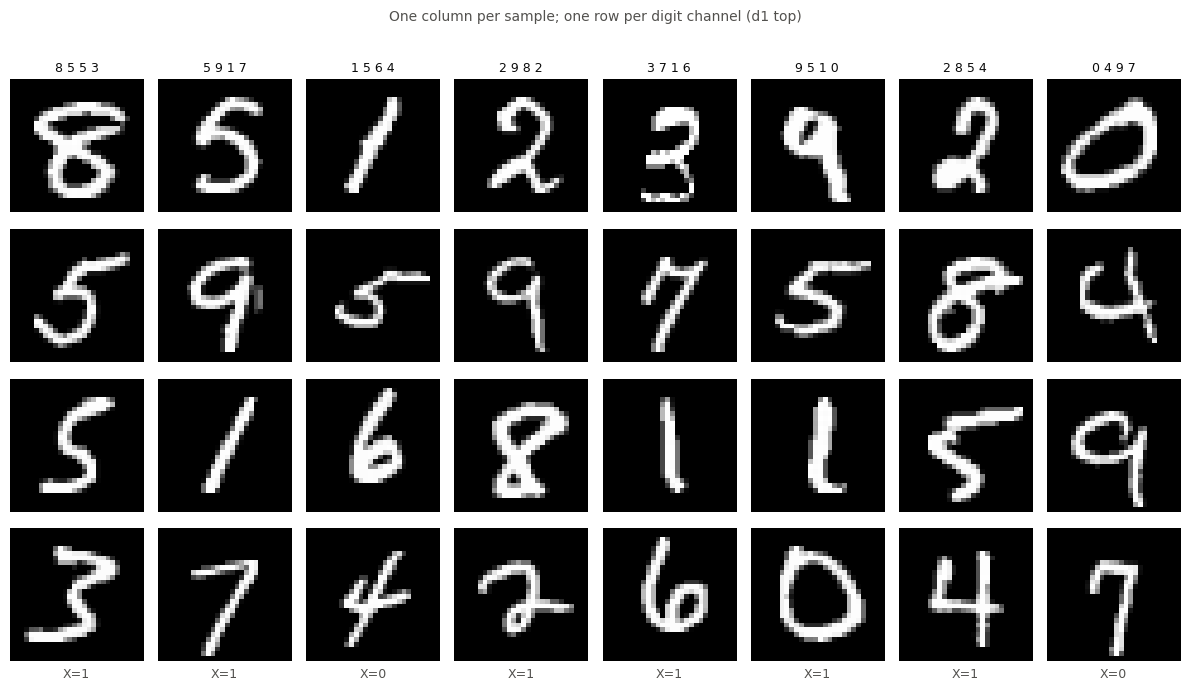

In [18]:
show_samples(trainset, range(8))

---

# 9. Auxiliary digit supervision — a diagnostic, not Test 1

Everything above is Test 1: the encoder gets **only** the X label, exactly the information
budget the Residual SCBM's residual head has. The result was marginal — `+0.0169` AUROC
over the concept-only ceiling at corruption 0.2.

This section asks a different question, to find out *why*. It adds two 10-way heads
predicting **d1 and d2** directly, so the encoder is told what the digits are.

**Read the ceiling differently here.** X is a deterministic function of d1 and d2. Once
the digit heads work, clearing the concept-only ceiling is close to guaranteed — so a
"pass" in this section is **not** the same claim as a pass in Test 1, and this number must
never be quoted as the Test 1 result. The real SCBM never sees digit labels.

What this *does* separate:

| observation | what it means |
|---|---|
| d1/d2 stay near chance (0.10) even with supervision | the encoder cannot resolve digits at this corruption — that alone explains the marginal Test 1 result |
| d1/d2 high, X margin still flat | digits are legible; the failure is composing them into the carry, which points at the head, not the encoder |
| X margin climbs with `lam_d` | the capacity was there and plain BCE was too weak a signal to find it — a real finding, but an upper bound the SCBM cannot reach |

`lam_d` is swept because the loss is badly unbalanced by default. There are **two** CE
terms, and CE over 10 classes starts near ln 10 ≈ 2.30 while BCE starts near ln 2 ≈ 0.69 —
so at `lam_d=1.0` the X objective receives only about 14% of the gradient. `lam_d=0.5`
weights the aux contribution to one head's worth, matching the single BCE. `lam_d=0.0` is
the control.

### The model — shared encoder, three heads

In [19]:
class AuxDigitModel(nn.Module):
    """Shared encoder + X logit + 10-way heads for d1 and d2."""
    def __init__(self, in_channels):
        super().__init__()
        self.encoder = IntCEMMNISTEncoder(in_channels=in_channels, output_dim=128)
        self.x_head  = nn.Linear(128, 1)
        self.d1_head = nn.Linear(128, 10)
        self.d2_head = nn.Linear(128, 10)

    def forward(self, x):
        h = self.encoder(x)
        return {"x": self.x_head(h).squeeze(1),
                "d1": self.d1_head(h),
                "d2": self.d2_head(h)}


class XOnly(nn.Module):
    """Wrapper so the imported evaluate() sees a single X logit, as before."""
    def __init__(self, aux):
        super().__init__()
        self.aux = aux

    def forward(self, x):
        return self.aux(x)["x"].unsqueeze(1)

### Training

Same optimiser, schedule, loop order and patience as §6. Two deviations from `train.py`,
both deliberate: the target is X, and early stopping tracks val **AUROC** rather than
accuracy (AUROC is the sensitive metric here, for the same reason §4 reports both).

Note `best` is keyed on `val_auroc`, not `val_acc` — the reporting cell below reads that
key. If you copy the §7 print block up here it will raise `KeyError: 'val_acc'`.

In [20]:
@torch.no_grad()
def digit_accuracy(model, loader, device):
    model.eval()
    hits = torch.zeros(2); n = 0
    for batch in loader:
        out = model(batch["features"].to(device))
        digits = batch["digit_labels"].to(device)
        hits[0] += (out["d1"].argmax(1) == digits[:, 0]).sum().cpu()
        hits[1] += (out["d2"].argmax(1) == digits[:, 1]).sum().cpu()
        n += digits.size(0)
    return (hits / n).tolist()


def train_aux(config, model, x_view, loaders, extract, device, lam_x=1.0, lam_d=1.0,
              verbose=True):
    m = config.model
    optimizer = optim.Adam(model.parameters(), lr=m.learning_rate, weight_decay=m.weight_decay)
    lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=m.decrease_every,
                                             gamma=1 / m.lr_divisor)
    bce, ce = nn.BCEWithLogitsLoss(), nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "val_acc": [], "val_auroc": [],
               "val_d1_acc": [], "val_d2_acc": []}
    best = {"val_auroc": float("-inf"), "epoch": -1, "state": None}
    stale = 0

    if verbose:
        print(f"{'epoch':>6} {'loss':>8} {'x_acc':>7} {'x_auroc':>8} {'d1_acc':>7} {'d2_acc':>7}")
    for epoch in range(m.j_epochs):
        val_acc, val_auroc = evaluate(x_view, loaders["val"], extract, device)
        d1_acc, d2_acc = digit_accuracy(model, loaders["val"], device)

        if val_auroc > best["val_auroc"]:
            best = {"val_auroc": val_auroc, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            stale = 0
        else:
            stale += 1
        if stale >= m.early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}; best val AUROC {best['val_auroc']:.4f}")
            break

        model.train()
        running, seen = 0.0, 0
        for batch in loaders["train"]:
            x = batch["features"].to(device)
            t_x = extract(batch).float().to(device)
            digits = batch["digit_labels"].to(device)          # [B, 4]
            out = model(x)
            loss = (lam_x * bce(out["x"], t_x)
                    + lam_d * (ce(out["d1"], digits[:, 0]) + ce(out["d2"], digits[:, 1])))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        lr_scheduler.step()

        for k, v in zip(["epoch", "train_loss", "val_acc", "val_auroc", "val_d1_acc", "val_d2_acc"],
                        [epoch, running / seen, val_acc, val_auroc, d1_acc, d2_acc]):
            history[k].append(v)
        if verbose:
            print(f"{epoch:>6} {running/seen:>8.4f} {val_acc:>7.4f} {val_auroc:>8.4f} "
                  f"{d1_acc:>7.4f} {d2_acc:>7.4f}")

    model.load_state_dict(best["state"])
    return history, best

### A single run

`lam_d=0.5` — the setting that equalises the aux term against the single BCE. Change it to
explore before committing to the sweep below.

In [21]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# LAM_D = 0.5
#
# reset_random_seeds(config.seed)
# torch.use_deterministic_algorithms(False)
#
# aux_model = AuxDigitModel(int(config.data.num_covariates)).to(device)
# x_view = XOnly(aux_model)
#
# aux_history, aux_best = train_aux(config, aux_model, x_view, loaders, extract, device,
#                                   lam_d=LAM_D)


In [22]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# test_acc, test_auroc = evaluate(x_view, loaders["test"], extract, device)
# d1, d2 = digit_accuracy(aux_model, loaders["test"], device)
#
# print(f"best epoch : {aux_best['epoch']} (val AUROC {aux_best['val_auroc']:.4f})\n")
# print(f"X    acc {test_acc:.4f} ({test_acc - ceiling_acc:+.4f})   "
#       f"AUROC {test_auroc:.4f} ({test_auroc - ceiling_auroc:+.4f})")
# print(f"     ceilings: accuracy {ceiling_acc:.3f}, AUROC {ceiling_auroc:.3f}")
# print(f"d1   acc {d1:.4f}   d2 acc {d2:.4f}   (chance = 0.10)")


In [23]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# # Two-stage readout: the model's own digit predictions -> carry rule.
# # Same encoder, same weights as the X head; only the extraction step differs.
#
# from sklearn.metrics import roc_auc_score
#
# # Carry table over (d1, d2): C[i, j] = 1[i + j >= 10]
# C = (torch.arange(10)[:, None] + torch.arange(10)[None, :] >= 10).float().to(device)
#
# aux_model.eval()
# x_true, x_head, x_hard, x_soft, d1_ok, d2_ok = [], [], [], [], [], []
# with torch.no_grad():
#     for batch in loaders["test"]:
#         out = aux_model(batch["features"].to(device))
#         digits = batch["digit_labels"].to(device)
#         t = extract(batch).float().to(device)
#
#         d1h, d2h = out["d1"].argmax(1), out["d2"].argmax(1)
#         p1, p2 = out["d1"].softmax(1), out["d2"].softmax(1)          # [B, 10]
#
#         x_true.append(t.cpu())
#         x_head.append(out["x"].cpu())                                # linear X logit
#         x_hard.append(C[d1h, d2h].cpu())                             # argmax -> rule
#         x_soft.append(torch.einsum("bi,ij,bj->b", p1, C, p2).cpu())  # P(X=1) under the digit posteriors
#         d1_ok.append((d1h == digits[:, 0]).cpu())
#         d2_ok.append((d2h == digits[:, 1]).cpu())
#
# x_true = torch.cat(x_true); x_head = torch.cat(x_head)
# x_hard = torch.cat(x_hard); x_soft = torch.cat(x_soft)
# d1_ok = torch.cat(d1_ok);   d2_ok = torch.cat(d2_ok)
#
# acc = lambda s, thr: ((s >= thr).float() == x_true).float().mean().item()
# auc = lambda s: roc_auc_score(x_true.numpy(), s.numpy())
#
# print(f"{'readout':26}{'acc':>8}{'AUROC':>8}")
# print(f"{'linear X head':26}{acc(x_head, 0.0):>8.4f}{auc(x_head):>8.4f}")
# print(f"{'two-stage, argmax':26}{acc(x_hard, 0.5):>8.4f}{auc(x_hard):>8.4f}")
# print(f"{'two-stage, soft':26}{acc(x_soft, 0.5):>8.4f}{auc(x_soft):>8.4f}")
# print(f"{'concept-only ceiling':26}{ceiling_acc:>8.4f}{ceiling_auroc:>8.4f}")
#
# # Where the two-stage readout loses: both digits right vs at least one wrong.
# both = d1_ok & d2_ok
# print(f"\nboth digits correct on {both.float().mean():.3f} of test samples")
# print(f"  two-stage acc | both correct : {(x_hard[both] == x_true[both]).float().mean():.4f}")
# print(f"  two-stage acc | >=1 wrong    : {(x_hard[~both] == x_true[~both]).float().mean():.4f}")


### The `lam_d` sweep

Everything is held fixed except `lam_d`: same loaders, same ceilings, same split, and the
seed is reset before each model so the initialisations are comparable.

Five full training runs — expect this to take a while.

In [24]:
# LAM_D_SWEEP = [0.0, 0.1, 0.3, 0.5, 1.0]

# aux_rows = []
# for lam_d in LAM_D_SWEEP:
#     reset_random_seeds(config.seed)
#     torch.use_deterministic_algorithms(False)

#     mdl = AuxDigitModel(int(config.data.num_covariates)).to(device)
#     xv = XOnly(mdl)
#     _, bst = train_aux(config, mdl, xv, loaders, extract, device,
#                        lam_d=lam_d, verbose=False)

#     acc, auroc = evaluate(xv, loaders["test"], extract, device)
#     d1_acc, d2_acc = digit_accuracy(mdl, loaders["test"], device)

#     aux_rows.append({"lam_d": lam_d, "acc": acc, "auroc": auroc,
#                      "acc_margin": acc - ceiling_acc,
#                      "auroc_margin": auroc - ceiling_auroc,
#                      "d1": d1_acc, "d2": d2_acc, "best_epoch": bst["epoch"]})
#     print(f"lam_d={lam_d:<4}  X acc {acc:.4f} ({acc - ceiling_acc:+.4f})  "
#           f"AUROC {auroc:.4f} ({auroc - ceiling_auroc:+.4f})  "
#           f"d1 {d1_acc:.4f}  d2 {d2_acc:.4f}  best_ep {bst['epoch']}")

In [25]:
if "aux_rows" not in globals() or not aux_rows:
    print("No results yet - run the LAM_D_SWEEP cell above "
          "(it may be commented out).")
else:
    lams = [r["lam_d"] for r in aux_rows]

    fig, (ax_x, ax_d) = plt.subplots(1, 2, figsize=(11, 4))

    # Left: what the X objective achieved, as a margin over the concept-only ceiling.
    ax_x.plot(lams, [r["acc_margin"] for r in aux_rows],
              color=SERIES_1, marker="o", label="accuracy", zorder=3)
    ax_x.plot(lams, [r["auroc_margin"] for r in aux_rows],
              color=SERIES_2, marker="o", label="AUROC", zorder=3)
    margins = [r["acc_margin"] for r in aux_rows] + [r["auroc_margin"] for r in aux_rows]
    lo, hi = min(-0.05, min(margins) - 0.02), max(0.05, max(margins) + 0.02)
    ax_x.set_ylim(lo, hi)
    ax_x.axhspan(lo, 0, color=GRID, alpha=0.4, zorder=0)
    ax_x.axhline(0, color=INK_2, linewidth=1.5, zorder=1)
    ax_x.annotate("concept-only ceiling", xy=(0.02, 0), xycoords=("axes fraction", "data"),
                  ha="left", va="bottom", fontsize=8, color=INK_2)
    ax_x.set_title("X: margin over the (A, B) ceiling")
    ax_x.set_xlabel("lam_d  (weight on the digit loss)")
    ax_x.set_ylabel("margin over ceiling")
    ax_x.legend(loc="best")

    # Right: can the encoder resolve the digits at all? Separate panel, not a second
    # y-axis -- these are absolute accuracies, not margins.
    ax_d.plot(lams, [r["d1"] for r in aux_rows], color=SERIES_1, marker="o", label="d1", zorder=3)
    ax_d.plot(lams, [r["d2"] for r in aux_rows], color=SERIES_2, marker="o", label="d2", zorder=3)
    ax_d.axhline(0.10, color=INK_MUTE, linestyle="--", linewidth=1.2)
    ax_d.annotate("chance (0.10)", xy=(0.02, 0.10), xycoords=("axes fraction", "data"),
                  ha="left", va="bottom", fontsize=8, color=INK_2)
    ax_d.set_ylim(0, 1)
    ax_d.set_title("Digits: can the encoder resolve d1 and d2?")
    ax_d.set_xlabel("lam_d  (weight on the digit loss)")
    ax_d.set_ylabel("test accuracy")
    ax_d.legend(loc="best")

    plt.tight_layout()
    plt.show()


No results yet - run the LAM_D_SWEEP cell above (it may be commented out).


### Reading the two panels together

The left panel is **not** a Test 1 result — with digit supervision the model is handed the
two variables X is computed from, so a positive margin there is expected and does not say
the residual channel could do the same.

The right panel is the load-bearing one. It answers whether the encoder can see the digits
at this corruption level, which is the precondition for anything downstream:

- **Digit accuracy near chance across the sweep** → the encoder cannot resolve d1/d2 at
  corruption 0.2, so it cannot compute the carry, and the marginal Test 1 result is
  explained mechanically. The fix is the input, not the architecture.
- **Digit accuracy high, X margin flat** → the digits are legible and the composition step
  is what fails. That points at the head, and a nonlinear head becomes worth testing —
  though note the IntCEM paper reports the same thing on MNIST-Add, and that a linear head
  cannot shortcut X is the premise the whole carry design rests on.
- **Both rise with `lam_d`** → the capacity exists but the X signal alone is too weak to
  find it. Worth reporting, and worth pairing with the corruption sweep in §8: the window
  where Σ stays alive *and* digits stay legible is what the experiment needs.

Whatever this shows, the number that goes in the writeup as "the encoder's capacity to
recover X" is the §7 one at `lam_d = 0`, not anything from this section.

---

# 10. Pretrain the encoder on digits

§9 trained X and the digits *jointly*, which made the two objectives compete for the same
gradient. This instead pretrains the encoder on **digit identity alone**, on all four
channels, then saves it — so §11 can ask what X is recoverable from a representation that
demonstrably encodes the digits.

Two heads' worth of note before running:

- **All four channels get a head**, d3 and d4 included, even though they are distractors
  that carry nothing about X. That is deliberate: it keeps the encoder's job symmetric
  across channels, so a later "d1/d2 are represented, d3/d4 are not" finding would be a
  fact about training rather than about which heads existed.
- **This is still not Test 1.** The digit labels are supervision the Residual SCBM never
  receives. What comes out is an upper bound on what the residual could carry, and the
  number that goes in the writeup as encoder capacity remains the §7 one.

Unlike §6, validation happens **after** each epoch here rather than before — this is a
standalone pretraining loop, not the matched replication, so `train.py`'s ordering quirk
does not apply.

In [26]:
class DigitBackbone(nn.Module):
    def __init__(self, in_channels, n_heads, feat_dim=128):
        super().__init__()
        self.encoder = IntCEMMNISTEncoder(in_channels=in_channels, output_dim=feat_dim)
        self.heads = nn.ModuleList([nn.Linear(feat_dim, 10) for _ in range(n_heads)])

    def forward(self, x):
        h = self.encoder(x)
        return h, [head(h) for head in self.heads]


@torch.no_grad()
def digit_acc_all(model, loader):
    model.eval(); hits = None; n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        d = batch["digit_labels"].to(device)
        h = torch.stack([(lg.argmax(1) == d[:, k]).sum() for k, lg in enumerate(logits)])
        hits = h if hits is None else hits + h; n += d.size(0)
    return (hits.float() / n).cpu().tolist()


def pretrain_digits(model, min_epochs=20):
    m = config.model
    opt = optim.Adam(model.parameters(), lr=m.learning_rate, weight_decay=m.weight_decay)
    sched = optim.lr_scheduler.StepLR(opt, step_size=m.decrease_every, gamma=1 / m.lr_divisor)
    ce = nn.CrossEntropyLoss()
    best = {"val": -1, "epoch": -1, "state": None}; stale = 0
    print(f"{'ep':>4} {'loss':>8} {'val mean':>9}   d1     d2     d3     d4")
    for epoch in range(m.j_epochs):
        model.train(); running = seen = 0
        for batch in loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            _, logits = model(x)
            loss = sum(ce(lg, d[:, k]) for k, lg in enumerate(logits))
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        sched.step()
        accs = digit_acc_all(model, loaders["val"]); vm = float(np.mean(accs))
        print(f"{epoch:>4} {running/seen:>8.4f} {vm:>9.4f}   " + "  ".join(f"{a:.3f}" for a in accs))
        if vm > best["val"]:
            best = {"val": vm, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            stale = 0
        else:
            stale += 1
        if epoch + 1 >= min_epochs and stale >= m.early_stopping_patience:
            print(f"early stop; best val {best['val']:.4f} @ epoch {best['epoch']}"); break
    model.load_state_dict(best["state"])
    return best

In [27]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# reset_random_seeds(config.seed)
# torch.use_deterministic_algorithms(False)
#
# backbone = DigitBackbone(int(config.data.num_covariates),
#                          int(config.data.num_covariates)).to(device)
# bb_best = pretrain_digits(backbone, min_epochs=20)
#
# print("\ntest digit acc:", " ".join(f"{a:.4f}" for a in digit_acc_all(backbone, loaders["test"])))
#
# OUT = REPO_ROOT / "experiments" / "backbones" / f"carry_c{config.data.corruption_strength}_s{config.seed}"
# OUT.mkdir(parents=True, exist_ok=True)
# torch.save(backbone.encoder.state_dict(), OUT / "encoder.pt")
# print("saved", OUT / "encoder.pt")


---

# 10b. A per-channel encoder — give each digit its own capacity

§10 pushes all four digits through one conv stack whose first layer sees them as four
*channels of one image*, then squeezes the result into a single 128-d vector. Channel-mixing
happens immediately, at conv1, and every downstream feature is shared.

`PerChannelMNISTEncoder` changes that: **one shared single-digit CNN**, applied to each
channel independently, outputs concatenated. With `output_dim=128` and four channels each
digit owns a private 32-d slice, and the weights that read a digit are the same weights for
every position — the natural inductive bias for "four independent MNIST digits", which the
stacked layout does not have.

Training is `pretrain_digits` **unchanged** from §10, so the only thing that differs between
the two rows below is the encoder.

**One caveat to state when you use this.** This swaps two things at once: per-channel
processing *and* a bigger, deeper network (32→64→64 conv with a 576→128→32 head, roughly
2× the stacked encoder's parameters). So a win here is evidence for "the stacked layout is
the wrong inductive bias **or** it is undersized", not a clean separation of the two. §10c
is the control that isolates capacity-per-digit; the cell below prints both parameter
counts so the confound stays visible.

In [28]:
class PerChannelMNISTEncoder(nn.Module):
    """One shared single-digit CNN applied to each channel; features concatenated."""
    def __init__(self, in_channels=4, output_dim=128):
        super().__init__()
        assert output_dim % in_channels == 0
        d = output_dim // in_channels
        self.in_channels = in_channels
        self.digit_net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(),
            nn.MaxPool2d(2),                                        # 28 -> 14
            nn.Conv2d(32, 64, 3, padding="same"), nn.BatchNorm2d(64), nn.LeakyReLU(),
            nn.MaxPool2d(2),                                        # 14 -> 7
            nn.Conv2d(64, 64, 3, padding="same"), nn.BatchNorm2d(64), nn.LeakyReLU(),
            nn.MaxPool2d(2),                                        # 7 -> 3
            nn.Flatten(),                                           # 64 * 9 = 576
            nn.Linear(576, 128), nn.LeakyReLU(), nn.Dropout(0.25),
            nn.Linear(128, d),
        )

    def forward(self, x):                                           # [B, C, 28, 28]
        feats = [self.digit_net(x[:, k:k+1]) for k in range(self.in_channels)]
        return torch.cat(feats, dim=1)                              # [B, C * d]


class BackboneFrom(nn.Module):
    """DigitBackbone with the encoder injected, so §10's pretrain_digits can train
    either architecture without being touched."""
    def __init__(self, encoder, n_heads, feat_dim=128):
        super().__init__()
        self.encoder = encoder
        self.heads = nn.ModuleList([nn.Linear(feat_dim, 10) for _ in range(n_heads)])

    def forward(self, x):
        h = self.encoder(x)
        return h, [head(h) for head in self.heads]

In [29]:
reset_random_seeds(config.seed)
torch.use_deterministic_algorithms(False)

n_ch = int(config.data.num_covariates)
pc_backbone = BackboneFrom(PerChannelMNISTEncoder(in_channels=n_ch, output_dim=128),
                           n_heads=n_ch).to(device)

pc_best = pretrain_digits(pc_backbone, min_epochs=20)      # §10's loop, unchanged

pc_test = digit_acc_all(pc_backbone, loaders["test"])
n_pc = sum(p.numel() for p in pc_backbone.parameters())
print(f"\nper-channel  test digit acc : " + "  ".join(f"{a:.4f}" for a in pc_test)
      + f"   (mean {np.mean(pc_test):.4f}, {n_pc:,} params)")

# §10's stacked backbone is optional here -- it is disabled when only the
# per-channel path is being run.
if "backbone" in globals():
    stacked_test = digit_acc_all(backbone, loaders["test"])
    n_stacked = sum(p.numel() for p in backbone.parameters())
    print(f"stacked      test digit acc : " + "  ".join(f"{a:.4f}" for a in stacked_test)
          + f"   (mean {np.mean(stacked_test):.4f}, {n_stacked:,} params)")
    print(f"\nmean gap: {np.mean(pc_test) - np.mean(stacked_test):+.4f}"
          f"   (per-channel is {n_pc / n_stacked:.1f}x the parameters)")
else:
    print("(§10 stacked backbone not in memory -- skipping the comparison.)")

PC_OUT = REPO_ROOT / "experiments" / "backbones" / (
    f"carry_c{config.data.corruption_strength}_s{config.seed}_perchannel")
PC_OUT.mkdir(parents=True, exist_ok=True)
torch.save(pc_backbone.encoder.state_dict(), PC_OUT / "encoder.pt")
print("saved", PC_OUT / "encoder.pt")

  ep     loss  val mean   d1     d2     d3     d4


/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


   0   8.2628    0.5690   0.538  0.593  0.614  0.531
   1   3.7186    0.9139   0.916  0.915  0.917  0.907
   2   1.1886    0.9620   0.970  0.960  0.957  0.962
   3   0.6326    0.9722   0.976  0.972  0.971  0.970
   4   0.4445    0.9768   0.980  0.978  0.974  0.976
   5   0.3414    0.9804   0.982  0.980  0.978  0.981
   6   0.2676    0.9820   0.983  0.981  0.983  0.981
   7   0.2188    0.9835   0.984  0.984  0.983  0.984
   8   0.1776    0.9854   0.985  0.986  0.985  0.985
   9   0.1460    0.9855   0.987  0.985  0.985  0.985
  10   0.1253    0.9854   0.987  0.985  0.986  0.984
  11   0.1061    0.9859   0.987  0.985  0.986  0.985
  12   0.0874    0.9859   0.985  0.986  0.985  0.987
  13   0.0774    0.9868   0.988  0.987  0.987  0.986
  14   0.0647    0.9873   0.989  0.986  0.988  0.986
  15   0.0551    0.9866   0.987  0.987  0.986  0.987
  16   0.0454    0.9867   0.989  0.984  0.989  0.985
  17   0.0427    0.9876   0.988  0.988  0.988  0.987
  18   0.0379    0.9873   0.987  0.988  0.988 

In [30]:
if "stacked_test" not in globals():
    print("Run §10 (stacked pretraining) to draw this comparison.")
else:
    xs = np.arange(len(pc_test))
    w = 0.36

    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(xs - w/2, stacked_test, w, color=SERIES_1, label="stacked (IntCEM encoder)", zorder=3)
    ax.bar(xs + w/2, pc_test, w, color=SERIES_2, label="per-channel (shared digit CNN)", zorder=3)

    for x, (a, b) in enumerate(zip(stacked_test, pc_test)):
        ax.annotate(f"{a:.3f}", xy=(x - w/2, a), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=INK_2)
        ax.annotate(f"{b:.3f}", xy=(x + w/2, b), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=INK_2)

    ax.axhline(0.10, color=INK_MUTE, linestyle="--", linewidth=1.2, zorder=1)
    ax.annotate("chance (0.10)", xy=(0.015, 0.10), xycoords=("axes fraction", "data"),
                ha="left", va="bottom", fontsize=8, color=INK_2)

    ax.set_xticks(xs); ax.set_xticklabels([f"d{k+1}" for k in xs])
    ax.set_ylim(0, 1.25)
    ax.set_ylabel("test digit accuracy")
    ax.set_title("Per-digit accuracy: shared per-channel CNN vs. stacked channels")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()


Run §10 (stacked pretraining) to draw this comparison.


### Using this encoder downstream

§11 reads its encoder from `load_pretrained_encoder`, which defaults to §10's `OUT/encoder.pt`
(the stacked one). To run the frozen/finetune probes on **this** encoder instead, rebuild it
and point the loader at `PC_OUT`:

```python
enc = PerChannelMNISTEncoder(in_channels=int(config.data.num_covariates), output_dim=128)
enc.load_state_dict(torch.load(PC_OUT / "encoder.pt", map_location="cpu"))
enc = enc.to(device)
```

Then pass `enc` to `ProbeModel(enc, frozen=True)`, or to §12's `extract_features`. That is
the interesting version of the §12 question: if the digits are represented *cleanly and
separately*, is the carry linearly decodable from them? A linear probe that still stalls on
a representation this good is a much stronger statement than one that stalls on the stacked
features, because "the features were poor" stops being an available explanation.

---

# 10c. Single-channel control — is the encoder capacity-bound?

§10 trains one encoder to read **four** digits stacked as channels, through a single 128-d
feature vector. This trains the *same encoder class* on **one** digit: `in_channels=1`, one
head, fed `x[:, :1]` against `digit_labels[:, 0]`.

If the stacked version lands near 91% and this lands near 98–99%, the gap is the argument:
the encoder is not failing to read digits in principle, it is being asked to represent four
of them at once through a bottleneck sized for one, and per-digit fidelity pays for it.
That reframes every downstream result — a marginal X margin would then be a consequence of
the *input format*, not of encoder capacity in any absolute sense, and `num_covariates` is
the knob to turn.

**The comparison is only worth making if nothing else differs**, so this reuses
`DigitBackbone` unchanged and mirrors `pretrain_digits` exactly: same optimiser, learning
rate, weight decay, StepLR schedule, batch size, epoch budget, patience, and the same
val-mean-accuracy early-stopping rule. Only the channel count and head count change.

**Parameters do not explain the gap, and they cut the wrong way.** Going 4→1 channels
*shrinks* the first conv (32×4×3×3 = 1152 → 32×1×3×3 = 288 weights) and drops three heads
(3 × 128 × 10 = 3840). So the single-channel model is the **smaller** one. If it wins
anyway, the stacked model's problem is what it is being asked to encode, not how many
weights it has.

Run §8b first — this control is only meaningful on clean digits, and the cell asserts it.

In [31]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# assert float(config.data.corruption_strength) == 0.0, (
#     f"corruption is {config.data.corruption_strength}; run the §8b clean-digits cell first"
# )
#
# CHANNEL = 0        # which digit channel to isolate; 0 -> d1, matching digit_labels[:, 0]
#
#
# def pretrain_single_channel(model, channel=0, min_epochs=20, verbose=True):
#     """pretrain_digits, restricted to one input channel and one head.
#
#     Structurally identical to §10's loop -- optimiser, schedule, patience and the
#     early-stopping metric all match -- so the only difference from the stacked run
#     is what the encoder is asked to represent.
#     """
#     m = config.model
#     opt = optim.Adam(model.parameters(), lr=m.learning_rate, weight_decay=m.weight_decay)
#     sched = optim.lr_scheduler.StepLR(opt, step_size=m.decrease_every, gamma=1 / m.lr_divisor)
#     ce = nn.CrossEntropyLoss()
#     best = {"val": -1, "epoch": -1, "state": None}; stale = 0
#
#     @torch.no_grad()
#     def val_acc(loader):
#         model.eval(); hits = 0; n = 0
#         for batch in loader:
#             x = batch["features"][:, channel:channel + 1].to(device)
#             d = batch["digit_labels"][:, channel].to(device)
#             _, logits = model(x)
#             hits += (logits[0].argmax(1) == d).sum().item(); n += d.size(0)
#         return hits / n
#
#     if verbose:
#         print(f"{'ep':>4} {'loss':>8} {'val acc':>9}")
#     for epoch in range(m.j_epochs):
#         model.train(); running = seen = 0
#         for batch in loaders["train"]:
#             x = batch["features"][:, channel:channel + 1].to(device)
#             d = batch["digit_labels"][:, channel].to(device)
#             _, logits = model(x)
#             loss = ce(logits[0], d)
#             opt.zero_grad(); loss.backward(); opt.step()
#             running += loss.item() * x.size(0); seen += x.size(0)
#         sched.step()
#
#         va = val_acc(loaders["val"])
#         if verbose:
#             print(f"{epoch:>4} {running/seen:>8.4f} {va:>9.4f}")
#         if va > best["val"]:
#             best = {"val": va, "epoch": epoch,
#                     "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
#             stale = 0
#         else:
#             stale += 1
#         if epoch + 1 >= min_epochs and stale >= m.early_stopping_patience:
#             print(f"early stop; best val {best['val']:.4f} @ epoch {best['epoch']}"); break
#
#     model.load_state_dict(best["state"])
#     return best, val_acc


In [32]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# reset_random_seeds(config.seed)
# torch.use_deterministic_algorithms(False)
#
# single = DigitBackbone(in_channels=1, n_heads=1).to(device)
# single_best, single_val_acc = pretrain_single_channel(single, channel=CHANNEL, min_epochs=20)
#
# single_test = single_val_acc(loaders["test"])
# stacked_test = digit_acc_all(backbone, loaders["test"])
#
# n_single = sum(p.numel() for p in single.parameters())
# n_stacked = sum(p.numel() for p in backbone.parameters())
#
# print(f"\nsingle-channel  d{CHANNEL+1} test acc : {single_test:.4f}   ({n_single:,} params)")
# print(f"stacked 4-chan  d{CHANNEL+1} test acc : {stacked_test[CHANNEL]:.4f}   ({n_stacked:,} params)")
# print(f"stacked, all digits          : " + "  ".join(f"{a:.4f}" for a in stacked_test))
# print(f"\ngap on d{CHANNEL+1}: {single_test - stacked_test[CHANNEL]:+.4f}")


In [33]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# labels = [f"d{k+1}\nstacked" for k in range(len(stacked_test))] + [f"d{CHANNEL+1}\nsingle"]
# values = list(stacked_test) + [single_test]
# colors = [SERIES_1] * len(stacked_test) + [SERIES_2]
#
# fig, ax = plt.subplots(figsize=(7.5, 4))
# bars = ax.bar(range(len(values)), values, color=colors, width=0.6, zorder=3)
#
# for x, v in enumerate(values):
#     ax.annotate(f"{v:.3f}", xy=(x, v), xytext=(0, 3), textcoords="offset points",
#                 ha="center", fontsize=8, color=INK_2)
#
# ax.axhline(0.10, color=INK_MUTE, linestyle="--", linewidth=1.2, zorder=1)
# ax.annotate("chance (0.10)", xy=(0.015, 0.10), xycoords=("axes fraction", "data"),
#             ha="left", va="bottom", fontsize=8, color=INK_2)
#
# ax.set_xticks(range(len(values))); ax.set_xticklabels(labels, fontsize=9)
# ax.set_ylim(0, 1.25)
# ax.set_ylabel("test digit accuracy")
# ax.set_title("One encoder reading four digits vs. the same encoder reading one")
# ax.grid(axis="x", visible=False)
#
# handles = [plt.Rectangle((0, 0), 1, 1, color=SERIES_1),
#            plt.Rectangle((0, 0), 1, 1, color=SERIES_2)]
# ax.legend(handles, ["4 channels stacked", "1 channel"], loc="upper left", ncol=2)
#
# plt.tight_layout()
# plt.show()


### What the gap means

- **Single ≫ stacked (e.g. 0.98 vs 0.91).** The encoder can read a digit essentially
  perfectly; stacking four through one 128-d bottleneck is what costs the fidelity. Every
  downstream result — the marginal X margin in §7, the frozen-probe gap in §11/§12 — is then
  partly an artefact of input format. The follow-up is `data.num_covariates`: if per-digit
  accuracy recovers as the channel count drops, capacity is the binding constraint and the
  carry experiment should be rerun at a width where the digits are actually legible.
- **Single ≈ stacked.** The bottleneck is not channel contention, and the stacked number is
  the encoder's honest ceiling on this input. Downstream results stand as they are.

Either way this does not change what Test 1 measured — it changes what the number is
*evidence about*. And note the single-channel model is the smaller of the two, so a win for
it cannot be explained by parameter count.

---

# 11. What is X, given an encoder that can read the digits?

This is the test §10 exists for. Three conditions, all evaluated against the same §4
ceilings, all trained with the same optimiser and schedule:

| condition | encoder | what it isolates |
|---|---|---|
| **scratch** | random init, trained | the §7 baseline — Test 1 proper |
| **frozen** | pretrained, weights fixed | is X *linearly decodable* from a digit representation? |
| **finetune** | pretrained, trained further | does a digit-aware starting point help at all? |

**frozen** is the informative one. If the encoder genuinely represents d1 and d2, and X is
still not linearly decodable from that representation, then the carry is simply not a
linear function of a digit-identity feature space — which is exactly the premise the
`hidden_carry` design rests on, and it would say the difficulty lives in the head, not the
encoder.

One implementation detail that matters: the encoder has **BatchNorm** layers. Setting
`requires_grad = False` stops the weights updating but does *not* stop BatchNorm's running
statistics drifting in train mode. The frozen condition therefore keeps the encoder in
`.eval()` throughout, otherwise "frozen" would be a misnomer.

In [34]:
def load_pretrained_encoder(config, device, path=None):
    path = path or (OUT / "encoder.pt")
    enc = IntCEMMNISTEncoder(in_channels=int(config.data.num_covariates), output_dim=128)
    enc.load_state_dict(torch.load(path, map_location="cpu"))
    return enc.to(device)


class ProbeModel(nn.Module):
    """Encoder + one linear X logit. `frozen` keeps the encoder in eval mode always,
    so BatchNorm running stats stay fixed too -- not just the weights."""

    def __init__(self, encoder, frozen):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(128, 1)
        self.frozen = frozen
        if frozen:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def train(self, mode=True):
        super().train(mode)
        if self.frozen:
            self.encoder.eval()      # overrides the .train() just applied above
        return self

    def forward(self, x):
        if self.frozen:
            with torch.no_grad():
                h = self.encoder(x)
        else:
            h = self.encoder(x)
        return self.head(h)


def run_condition(name, config, loaders, extract, device):
    reset_random_seeds(config.seed)
    torch.use_deterministic_algorithms(False)

    if name == "scratch":
        model = build_model(config, device)
    else:
        model = ProbeModel(load_pretrained_encoder(config, device),
                           frozen=(name == "frozen")).to(device)

    history, best = train_encoder(config, model, loaders, extract, device, verbose=False)
    acc, auroc = evaluate(model, loaders["test"], extract, device)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"condition": name, "acc": acc, "auroc": auroc,
            "acc_margin": acc - ceiling_acc, "auroc_margin": auroc - ceiling_auroc,
            "best_epoch": best["epoch"], "trainable": trainable}

In [35]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# probe_rows = [run_condition(n, config, loaders, extract, device)
#               for n in ("scratch", "frozen", "finetune")]
#
# print(f"{'condition':>10} {'X acc':>8} {'d(acc)':>8} {'X AUROC':>9} {'d(AUROC)':>9} "
#       f"{'best_ep':>8} {'trainable':>10}")
# for r in probe_rows:
#     print(f"{r['condition']:>10} {r['acc']:>8.4f} {r['acc_margin']:>+8.4f} "
#           f"{r['auroc']:>9.4f} {r['auroc_margin']:>+9.4f} {r['best_epoch']:>8} "
#           f"{r['trainable']:>10,}")
# print(f"\nceilings: accuracy {ceiling_acc:.4f}, AUROC {ceiling_auroc:.4f}")


In [36]:
if "probe_rows" not in globals() or not probe_rows:
    print("No results yet - run the probe_rows cell above "
          "(it may be commented out).")
else:
    names = [r["condition"] for r in probe_rows]
    xs = np.arange(len(names))
    w = 0.36

    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(xs - w/2, [r["acc_margin"] for r in probe_rows], w,
           color=SERIES_1, label="accuracy", zorder=3)
    ax.bar(xs + w/2, [r["auroc_margin"] for r in probe_rows], w,
           color=SERIES_2, label="AUROC", zorder=3)

    margins = [r["acc_margin"] for r in probe_rows] + [r["auroc_margin"] for r in probe_rows]
    lo, hi = min(-0.05, min(margins) - 0.02), max(0.05, max(margins) + 0.02)
    ax.set_ylim(lo, hi)
    ax.axhspan(lo, 0, color=GRID, alpha=0.4, zorder=0)
    ax.axhline(0, color=INK_2, linewidth=1.5, zorder=1)
    ax.annotate("concept-only ceiling", xy=(0.985, 0), xycoords=("axes fraction", "data"),
                ha="right", va="bottom", fontsize=8, color=INK_2)

    for x, r in zip(xs, probe_rows):
        for off, key in ((-w/2, "acc_margin"), (w/2, "auroc_margin")):
            v = r[key]
            ax.annotate(f"{v:+.3f}", xy=(x + off, v), xytext=(0, 3 if v >= 0 else -11),
                        textcoords="offset points", ha="center", fontsize=8, color=INK_2)

    ax.set_xticks(xs); ax.set_xticklabels(names)
    ax.set_title("X recoverability by encoder condition")
    ax.set_ylabel("margin over ceiling")
    ax.legend(loc="best")
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.show()


No results yet - run the probe_rows cell above (it may be commented out).


### Reading it

Compare **frozen** against **scratch**, and check both against §10's test digit accuracy.

- **Digit accuracy high, frozen margin still ≈ 0** — the strongest result available here.
  The encoder provably represents d1 and d2, yet X is not linearly readable from that
  representation. The carry is not a linear function of digit-identity features, so the
  bottleneck is the head, not encoder capacity. This would mean the `hidden_carry` design
  is doing exactly what it was built to do — a linear head genuinely cannot shortcut X —
  and the marginal Test 1 result is the expected consequence, not a bug.
- **frozen ≫ scratch** — X was always decodable; from-scratch training just never found
  the representation. An optimisation problem, and the Test 1 figure understates what the
  architecture can do.
- **frozen ≈ scratch ≈ 0, digit accuracy also low** — back to §8: corruption is destroying
  the input before any of this matters.

Whichever way it lands, pair it with the Σ-collapse check before drawing conclusions about
the residual channel. This notebook establishes recoverability; it does not establish what
an unsupervised residual will organise itself around.

---

# 12. Sanity-check the frozen probe with sklearn

§11's `frozen` row trains its linear head with Adam for a bounded number of epochs. That
head has 129 parameters sitting on fixed features, so it is a convex logistic regression —
and there is no reason to trust SGD to have found its optimum rather than stopped short of
it. If the frozen number is an underfit rather than a real ceiling, every conclusion drawn
from it is wrong in the same direction.

So: extract the frozen features once, fit the probe **to convergence** with L-BFGS, and see
whether §11's figure survives.

Two probes on identical features:

- **Logistic regression** — the same hypothesis class as §11's head, solved properly. This
  is what confirms or corrects that number.
- **A small MLP** — same features, non-linear head. This is the actual test of §11's
  hypothesis. If the linear probe stalls and the MLP does not, the carry is genuinely not a
  *linear* function of digit-identity features, and the bottleneck is the head rather than
  the encoder. If neither moves, the features do not carry X at all and the problem is
  upstream.

Features come from shuffle-free loaders built here, not `loaders["train"]` — that one has
`drop_last=True` and would silently discard up to a batch of training rows.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


@torch.no_grad()
def extract_features(encoder, dataset, extract, device, batch_size=512):
    """Frozen forward pass -> (features, targets). eval() so BatchNorm uses running stats."""
    encoder.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    H, Y = [], []
    for batch in loader:
        H.append(encoder(batch["features"].to(device)).cpu())
        Y.append(extract(batch))
    return torch.cat(H).numpy(), torch.cat(Y).numpy().astype(int)


# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# enc = load_pretrained_encoder(config, device)
# H_tr, y_tr = extract_features(enc, trainset, extract, device)
# H_va, y_va = extract_features(enc, valset, extract, device)
# H_te, y_te = extract_features(enc, testset, extract, device)
#
# scaler = StandardScaler().fit(H_tr)
# Z_tr, Z_va, Z_te = (scaler.transform(H) for H in (H_tr, H_va, H_te))
#
# print(f"features: train {Z_tr.shape}  val {Z_va.shape}  test {Z_te.shape}")
# print(f"P(X=1): train {y_tr.mean():.4f}  test {y_te.mean():.4f}")


### Linear probe, solved to convergence

`C` is chosen on validation AUROC, so the probe gets every chance the SGD head did not.

In [38]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# lin_rows = []
# for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
#     clf = LogisticRegression(C=C, max_iter=5000)
#     clf.fit(Z_tr, y_tr)
#     va = roc_auc_score(y_va, clf.decision_function(Z_va))
#     lin_rows.append({"C": C, "val_auroc": va, "clf": clf})
#     print(f"C={C:<7} val AUROC {va:.4f}")
#
# lin_best = max(lin_rows, key=lambda r: r["val_auroc"])
# lin_scores = lin_best["clf"].decision_function(Z_te)
# lin_acc = (lin_best["clf"].predict(Z_te) == y_te).mean()
# lin_auroc = roc_auc_score(y_te, lin_scores)
# print(f"\nbest C = {lin_best['C']}")
# print(f"linear probe   test acc {lin_acc:.4f} ({lin_acc - ceiling_acc:+.4f})   "
#       f"AUROC {lin_auroc:.4f} ({lin_auroc - ceiling_auroc:+.4f})")


### Non-linear probe on the *same* features

If this clears the linear probe by a wide margin, the information about X is present in the
frozen representation but not linearly separable there.

In [39]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# mlp = MLPClassifier(hidden_layer_sizes=(256,), max_iter=1000,
#                     early_stopping=True, random_state=config.seed)
# mlp.fit(Z_tr, y_tr)
# mlp_scores = mlp.predict_proba(Z_te)[:, 1]
# mlp_acc = (mlp.predict(Z_te) == y_te).mean()
# mlp_auroc = roc_auc_score(y_te, mlp_scores)
# print(f"MLP probe      test acc {mlp_acc:.4f} ({mlp_acc - ceiling_acc:+.4f})   "
#       f"AUROC {mlp_auroc:.4f} ({mlp_auroc - ceiling_auroc:+.4f})")


### Verdict: was §11's frozen number real?

In [40]:
# --- DISABLED: not needed for the §13 per-channel X probe. Uncomment to restore. ---
# sgd = next((r for r in probe_rows if r["condition"] == "frozen"),
#            None) if "probe_rows" in globals() else None
#
# print(f"{'probe':<24} {'test acc':>9} {'d(acc)':>9} {'AUROC':>9} {'d(AUROC)':>9}")
# if sgd is not None:
#     print(f"{'frozen, SGD head (S11)':<24} {sgd['acc']:>9.4f} {sgd['acc_margin']:>+9.4f} "
#           f"{sgd['auroc']:>9.4f} {sgd['auroc_margin']:>+9.4f}")
# print(f"{'frozen, logistic (L-BFGS)':<24} {lin_acc:>9.4f} {lin_acc - ceiling_acc:>+9.4f} "
#       f"{lin_auroc:>9.4f} {lin_auroc - ceiling_auroc:>+9.4f}")
# print(f"{'frozen, MLP head':<24} {mlp_acc:>9.4f} {mlp_acc - ceiling_acc:>+9.4f} "
#       f"{mlp_auroc:>9.4f} {mlp_auroc - ceiling_auroc:>+9.4f}")
# print(f"\nceilings: accuracy {ceiling_acc:.4f}, AUROC {ceiling_auroc:.4f}")
#
# if sgd is not None:
#     gap = lin_auroc - sgd["auroc"]
#     if gap > 0.02:
#         print(f"\nCORRECTED: the SGD head was underfit by {gap:+.4f} AUROC. Use the "
#               f"L-BFGS number as the frozen result.")
#     elif gap < -0.02:
#         print(f"\nThe SGD head BEAT the converged linear probe by {-gap:.4f} AUROC. That "
#               f"should not happen on fixed features -- suspect a feature-extraction "
#               f"mismatch (train/eval mode, scaler, or a different encoder checkpoint).")
#     else:
#         print(f"\nCONFIRMED: converged linear probe agrees with the SGD head "
#               f"({gap:+.4f} AUROC). The frozen figure is a real linear ceiling, not "
#               f"an optimisation artefact.")
#
# nonlin_gain = mlp_auroc - lin_auroc
# print(f"MLP over linear on the same features: {nonlin_gain:+.4f} AUROC -> "
#       + ("X is present but NOT linearly decodable; the head is the bottleneck."
#          if nonlin_gain > 0.03 else
#          "no non-linear headroom either; the features themselves do not carry X."))


---

### Fix: `DataLoader worker exited unexpectedly`

If §13 (or any later cell) dies with

```
RuntimeError: DataLoader worker (pid(s) ...) exited unexpectedly
```

the OS killed the worker processes under memory pressure. Three cells in this notebook
build loaders with `persistent_workers=True`, and the §8 corruption sweep does it *inside
its loop* — so a five-point sweep leaves ten loaders whose workers stay alive until garbage
collection gets to them. §13 is then the most demanding cell in the notebook (the
per-channel encoder runs `digit_net` once per channel, four times per batch), and something
has to give.

Worker processes are pure overhead for this dataset anyway: `_load_mnist_tensor` indexes an
in-memory tensor and divides by 255, so there is no I/O to overlap, and under spawn each
worker pays for its own copy of the 47 MB MNIST tensor. Running this cell drops to
`num_workers=0`, which is both the fix and slightly faster.

Set `config.workers = 0` in §2 to avoid the problem from the start.

In [41]:
import gc

# Release the lingering persistent workers before building anything new.
for _name in ("train_loader", "val_loader", "test_loader", "loaders",
              "sweep_loaders", "sample_loader"):
    if _name in globals():
        del globals()[_name]
gc.collect()

config.workers = 0      # every loader below reads this; keeps later rebuilds consistent

train_loader = DataLoader(
    trainset, batch_size=m.train_batch_size, shuffle=True,
    num_workers=0, generator=gen, drop_last=True,
)
val_loader = DataLoader(valset, batch_size=m.val_batch_size, shuffle=True,
                        num_workers=0, generator=gen)
test_loader = DataLoader(testset, batch_size=m.val_batch_size,
                         num_workers=0, generator=gen)
loaders = {"train": train_loader, "val": val_loader, "test": test_loader}

print(f"rebuilt loaders with num_workers=0 "
      f"(train {len(train_loader)} batches, val {len(val_loader)}, test {len(test_loader)})")

rebuilt loaders with num_workers=0 (train 187 batches, val 38, test 157)


---

# 13. The X task on the per-channel encoder

§10b produced an encoder that reads all four digits at **~98%**, matching what §10c gets
reading a single digit in isolation. §11 and §12 asked their questions of the *stacked*
encoder, whose digits sat at ~80%. This repeats both on the good representation.

This is the version of the question worth reporting. The frozen linear probe stalling on
stacked features admits an easy objection — the features were poor, so of course the carry
was not decodable from them. On a representation where each digit is read to 98% accuracy
in its own private 32-d slice, that objection is gone. If a **converged** linear probe still
cannot decode X from those features while a non-linear one can, the conclusion is about the
carry's relationship to digit-identity space, not about a weak encoder.

Everything is held to §11/§12's protocol: same three conditions, same `ProbeModel` (which
keeps a frozen encoder in `.eval()` so BatchNorm *and* the per-channel net's Dropout stay
fixed), same L-BFGS probe with `C` chosen on validation, same MLP, same ceilings.

Requires §10b to have run — it loads `PC_OUT/encoder.pt`.

In [42]:
def load_pc_encoder(config, device, path=None):
    path = path or (PC_OUT / "encoder.pt")
    enc = PerChannelMNISTEncoder(in_channels=int(config.data.num_covariates), output_dim=128)
    enc.load_state_dict(torch.load(path, map_location="cpu"))
    return enc.to(device)


def run_condition_pc(name, config, loaders, extract, device):
    """§11's run_condition, with the per-channel encoder in place of the stacked one."""
    reset_random_seeds(config.seed)
    torch.use_deterministic_algorithms(False)

    if name == "scratch":
        enc = PerChannelMNISTEncoder(in_channels=int(config.data.num_covariates),
                                     output_dim=128).to(device)
        model = ProbeModel(enc, frozen=False).to(device)
    else:
        model = ProbeModel(load_pc_encoder(config, device),
                           frozen=(name == "frozen")).to(device)

    history, best = train_encoder(config, model, loaders, extract, device, verbose=False)
    acc, auroc = evaluate(model, loaders["test"], extract, device)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"condition": name, "acc": acc, "auroc": auroc,
            "acc_margin": acc - ceiling_acc, "auroc_margin": auroc - ceiling_auroc,
            "best_epoch": best["epoch"], "trainable": trainable}


pc_probe_rows = [run_condition_pc(n, config, loaders, extract, device)
                 for n in ("scratch", "frozen", "finetune")]

print(f"{'condition':>10} {'X acc':>8} {'d(acc)':>8} {'X AUROC':>9} {'d(AUROC)':>9} "
      f"{'best_ep':>8} {'trainable':>10}")
for r in pc_probe_rows:
    print(f"{r['condition']:>10} {r['acc']:>8.4f} {r['acc_margin']:>+8.4f} "
          f"{r['auroc']:>9.4f} {r['auroc_margin']:>+9.4f} {r['best_epoch']:>8} "
          f"{r['trainable']:>10,}")
print(f"\nceilings: accuracy {ceiling_acc:.4f}, AUROC {ceiling_auroc:.4f}")

 condition    X acc   d(acc)   X AUROC  d(AUROC)  best_ep  trainable
   scratch   0.9081  +0.1081    0.9696   +0.0908       11    134,177
    frozen   0.8861  +0.0861    0.9603   +0.0815      104        129
  finetune   0.9136  +0.1136    0.9748   +0.0960       11    134,177

ceilings: accuracy 0.8000, AUROC 0.8788


### Converged probes on the per-channel frozen features

Same two probes as §12, same features-then-fit protocol. The linear/MLP gap here is the
number the whole notebook has been building toward.

In [43]:
pc_enc = load_pc_encoder(config, device)
P_tr, y_tr = extract_features(pc_enc, trainset, extract, device)
P_va, y_va = extract_features(pc_enc, valset, extract, device)
P_te, y_te = extract_features(pc_enc, testset, extract, device)

pc_scaler = StandardScaler().fit(P_tr)
Q_tr, Q_va, Q_te = (pc_scaler.transform(P) for P in (P_tr, P_va, P_te))

pc_lin_rows = []
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    clf = LogisticRegression(C=C, max_iter=5000)
    clf.fit(Q_tr, y_tr)
    va = roc_auc_score(y_va, clf.decision_function(Q_va))
    pc_lin_rows.append({"C": C, "val_auroc": va, "clf": clf})
    print(f"C={C:<7} val AUROC {va:.4f}")

pc_lin_best = max(pc_lin_rows, key=lambda r: r["val_auroc"])
pc_lin_acc = (pc_lin_best["clf"].predict(Q_te) == y_te).mean()
pc_lin_auroc = roc_auc_score(y_te, pc_lin_best["clf"].decision_function(Q_te))

pc_mlp = MLPClassifier(hidden_layer_sizes=(256,), max_iter=1000,
                       early_stopping=True, random_state=config.seed)
pc_mlp.fit(Q_tr, y_tr)
pc_mlp_acc = (pc_mlp.predict(Q_te) == y_te).mean()
pc_mlp_auroc = roc_auc_score(y_te, pc_mlp.predict_proba(Q_te)[:, 1])

print(f"\nbest C = {pc_lin_best['C']}")
print(f"linear probe   test acc {pc_lin_acc:.4f} ({pc_lin_acc - ceiling_acc:+.4f})   "
      f"AUROC {pc_lin_auroc:.4f} ({pc_lin_auroc - ceiling_auroc:+.4f})")
print(f"MLP probe      test acc {pc_mlp_acc:.4f} ({pc_mlp_acc - ceiling_acc:+.4f})   "
      f"AUROC {pc_mlp_auroc:.4f} ({pc_mlp_auroc - ceiling_auroc:+.4f})")
print(f"\nMLP over linear on identical features: {pc_mlp_auroc - pc_lin_auroc:+.4f} AUROC")

C=0.001   val AUROC 0.9228
C=0.01    val AUROC 0.9411
C=0.1     val AUROC 0.9583
C=1.0     val AUROC 0.9644
C=10.0    val AUROC 0.9657
C=100.0   val AUROC 0.9654

best C = 10.0
linear probe   test acc 0.9077 (+0.1077)   AUROC 0.9713 (+0.0925)
MLP probe      test acc 0.9784 (+0.1784)   AUROC 0.9965 (+0.1177)

MLP over linear on identical features: +0.0252 AUROC


### Stacked vs per-channel, side by side

In [44]:
def row_of(rows, name):
    return next((r for r in rows if r["condition"] == name), None)


_have_stacked = (globals().get("probe_rows") and "lin_auroc" in globals()
                 and "mlp_auroc" in globals())

if not _have_stacked:
    print("Stacked-encoder results (§11/§12) are not in memory, so this is the "
          "per-channel column only.\n")
    print(f"{'probe':<20} {'per-chan':>9}   (AUROC)")
    for label, key in (("scratch", "scratch"), ("frozen (SGD head)", "frozen"),
                       ("finetune", "finetune")):
        r = row_of(pc_probe_rows, key)
        print(f"{label:<20} {r['auroc']:>9.4f}")
    print(f"{'frozen + logistic':<20} {pc_lin_auroc:>9.4f}")
    print(f"{'frozen + MLP':<20} {pc_mlp_auroc:>9.4f}")
    print(f"\nceiling AUROC {ceiling_auroc:.4f}   |   per-channel digit acc "
          f"{np.mean(pc_test):.3f}")
    comparison = []
else:
    comparison = []
    for label, st, pc in (
        ("scratch",           row_of(probe_rows, "scratch"),  row_of(pc_probe_rows, "scratch")),
        ("frozen (SGD head)", row_of(probe_rows, "frozen"),   row_of(pc_probe_rows, "frozen")),
        ("finetune",          row_of(probe_rows, "finetune"), row_of(pc_probe_rows, "finetune")),
    ):
        comparison.append((label,
                           st["auroc"] if st else float("nan"),
                           pc["auroc"] if pc else float("nan")))
    comparison.append(("frozen + logistic", lin_auroc, pc_lin_auroc))
    comparison.append(("frozen + MLP", mlp_auroc, pc_mlp_auroc))

    print(f"{'probe':<20} {'stacked':>9} {'per-chan':>9} {'delta':>9}   (AUROC)")
    for label, a, b in comparison:
        print(f"{label:<20} {a:>9.4f} {b:>9.4f} {b - a:>+9.4f}")
    print(f"\nceiling AUROC {ceiling_auroc:.4f}   |   digit acc: "
          f"stacked {np.mean(stacked_test):.3f}, per-channel {np.mean(pc_test):.3f}")

Stacked-encoder results (§11/§12) are not in memory, so this is the per-channel column only.

probe                 per-chan   (AUROC)
scratch                 0.9696
frozen (SGD head)       0.9603
finetune                0.9748
frozen + logistic       0.9713
frozen + MLP            0.9965

ceiling AUROC 0.8788   |   per-channel digit acc 0.989


In [45]:
if not comparison:
    print("Nothing to compare -- run §11 and §12 for the stacked column.")
else:
    labels = [c[0] for c in comparison]
    stacked_vals = [c[1] - ceiling_auroc for c in comparison]
    pc_vals = [c[2] - ceiling_auroc for c in comparison]
    xs = np.arange(len(labels))
    w = 0.36

    fig, ax = plt.subplots(figsize=(9, 4.4))
    ax.bar(xs - w/2, stacked_vals, w, color=SERIES_1, label="stacked encoder", zorder=3)
    ax.bar(xs + w/2, pc_vals, w, color=SERIES_2, label="per-channel encoder", zorder=3)

    allv = stacked_vals + pc_vals
    lo, hi = min(-0.05, min(allv) - 0.03), max(0.05, max(allv) + 0.05)
    ax.set_ylim(lo, hi)
    ax.axhspan(lo, 0, color=GRID, alpha=0.4, zorder=0)
    ax.axhline(0, color=INK_2, linewidth=1.5, zorder=1)
    ax.annotate("concept-only ceiling", xy=(0.985, 0), xycoords=("axes fraction", "data"),
                ha="right", va="bottom", fontsize=8, color=INK_2)

    for x, (a, b) in enumerate(zip(stacked_vals, pc_vals)):
        for off, v in ((-w/2, a), (w/2, b)):
            ax.annotate(f"{v:+.3f}", xy=(x + off, v), xytext=(0, 3 if v >= 0 else -11),
                        textcoords="offset points", ha="center", fontsize=7.5, color=INK_2)

    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_ylabel("AUROC margin over ceiling")
    ax.set_title("X recoverability: stacked features vs. per-channel features")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()


Nothing to compare -- run §11 and §12 for the stacked column.


### What this settles

Read the **frozen + logistic** and **frozen + MLP** rows together, against the digit
accuracies printed alongside them.

- **Linear stalls below the ceiling, MLP clears it — on 98%-accurate digit features.** The
  carry is present in the representation and is not a linear function of digit identity.
  This is the claim `hidden_carry` was designed to produce, now established on features
  whose quality cannot be blamed. The consequence for the Residual SCBM is direct: its task
  head is linear, so it cannot read X off a concept-like representation no matter how good
  the encoder is, and the residual channel is the only route available. That makes a weak
  §7 margin the *expected* outcome, not a defect.
- **Both clear the ceiling on per-channel features but not stacked.** Then the stacked
  layout was the binding constraint all along, and every earlier figure in this notebook is
  an artefact of input format. `data.num_covariates` and the encoder architecture become the
  headline, and the carry experiment should be rerun with a per-channel encoder before any
  claim about the residual is made.
- **Neither clears it even here.** X is not recoverable from a digit-identity representation
  by these probe classes at all — which would be surprising given X is a deterministic
  function of d1 and d2, and would point at the probe setup rather than the model.

The standing caveat does not go away: all of this is supervised recoverability. It bounds
what the residual *could* carry; it says nothing about what an unsupervised residual channel
organises itself around. That question needs the Σ cross-block, and the Σ-collapse check
from `mnist_add_carry_analysis.ipynb` §3 alongside it.